In [6]:
!curl -OL https://github.com/neich/tvb-root-cpp/raw/main/python/dist/tvbcpp-0.0.3-cp38-cp38-linux_x86_64.whl
!pip install --force-reinstall tvbcpp-0.0.3-cp38-cp38-linux_x86_64.whl

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2913k  100 2913k    0     0  2140k      0  0:00:01  0:00:01 --:--:-- 16.4M
Processing ./tvbcpp-0.0.3-cp38-cp38-linux_x86_64.whl
  Attempting uninstall: tvbcpp
    Found existing installation: tvbcpp 0.0.3
    Uninstalling tvbcpp-0.0.3:
      Successfully uninstalled tvbcpp-0.0.3


Starting simulation, t_start =  0.0 , t_end =  10000.0
Simulation ended in  19420  msec


Results data freed!
Results data freed!


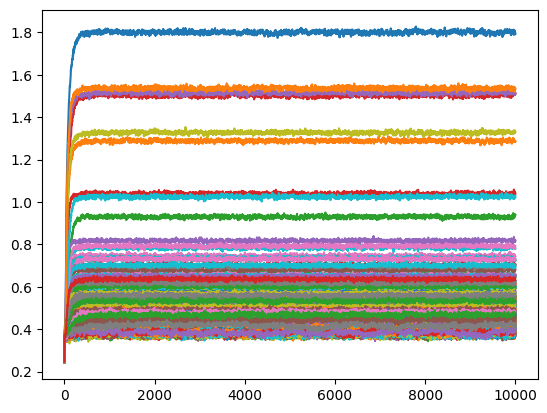

In [8]:
import tvbcpp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

m = np.genfromtxt("weights.csv", delimiter=',', dtype=np.float32)
tvbcpp.set_weights(m)

m = np.genfromtxt("lenghts.csv", delimiter=',', dtype=np.float32)
tvbcpp.set_lenghts(m, 1e6)

sigmas = np.array([1e-5, 1e-5, 0, 0], dtype=np.float32)
tvbcpp.set_integrator_es(0.1, sigmas)

tvbcpp.set_model("ReducedWongWangExcInh")
tvbcpp.set_model_parameter("G", 1.1)

tvbcpp.set_raw_monitor(1.0, [3])

d_raw = tvbcpp.run_sim(0, 10000)

fig, ax = plt.subplots()
ax.plot([n for n in range(0, d_raw.shape[0])], d_raw[:, 0, :]);
